In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")
df = clean_data.copy()
df.shape

(1853629, 37)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1853629 entries, 0 to 1853628
Data columns (total 37 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float32        
 5   fare_type_id                  int8           
 6   store_and_fwd_flag            boolean        
 7   pickup_location_id            int16          
 8   dropoff_location_id           int16          
 9   payment_type                  int64          
 10  fare_amount                   float64        
 11  extra_amount                  float64        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amou

# check fare_amount

In [94]:
df['fare_amount'].isna().sum()

np.int64(0)

In [95]:
df['fare_amount'].describe()

count    1.853629e+06
mean     2.249458e+01
std      2.003895e+01
min     -9.000000e+02
25%      1.140000e+01
50%      1.630000e+01
75%      2.680000e+01
max      9.000000e+02
Name: fare_amount, dtype: float64

<Axes: xlabel='fare_amount', ylabel='Density'>

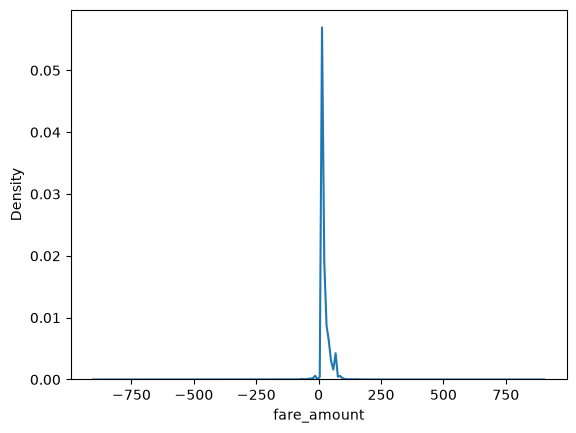

In [96]:
sns.kdeplot(df['fare_amount'])

In [97]:
df['fare_amount'].quantile([0.9, 0.99, 0.995, 0.999, 0.9995, 0.9999, 0.99995, 0.99999])

0.90000     46.500000
0.99000     80.400000
0.99500     92.000000
0.99900    159.800000
0.99950    204.600000
0.99990    328.500000
0.99995    385.200000
0.99999    582.608764
Name: fare_amount, dtype: float64

# check negative fare_amount

In [98]:
tempdf = df[(df['fare_amount'] < 0)]

In [99]:
df['payment_type'].value_counts()

payment_type
1    1605607
2     205946
4      34755
3       7321
Name: count, dtype: int64

In [100]:
tempdf['payment_type'].value_counts(normalize=True)

payment_type
4    0.682087
2    0.225721
3    0.090950
1    0.001241
Name: proportion, dtype: float64

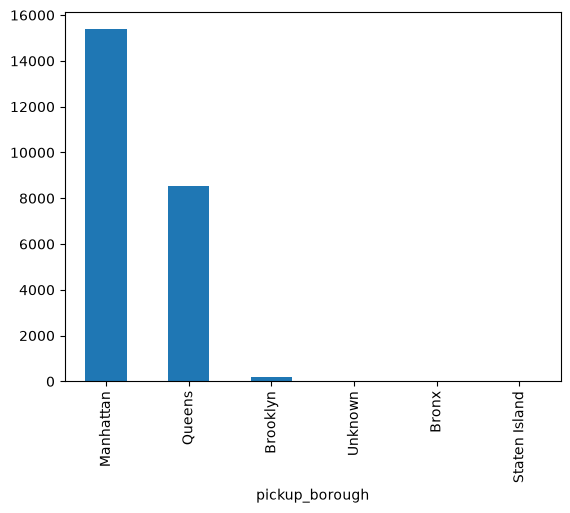

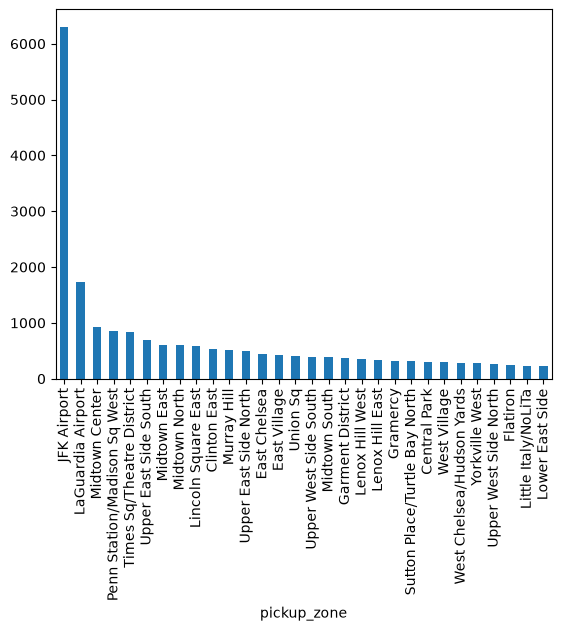

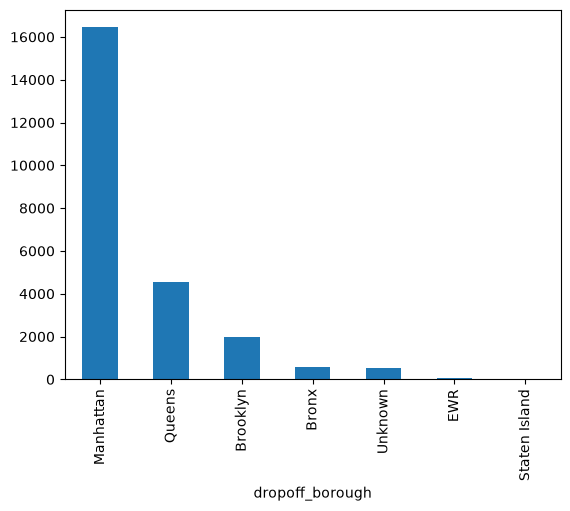

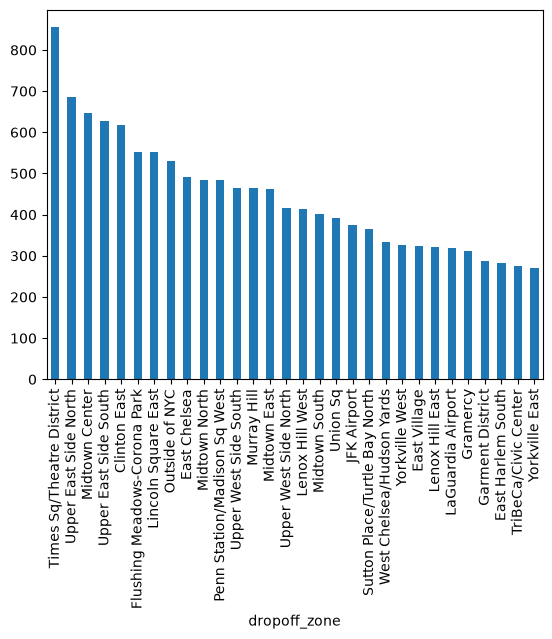

In [101]:
tempdf['pickup_borough'].value_counts().plot(kind='bar')
plt.show()

tempdf['pickup_zone'].value_counts().head(30).plot(kind='bar')
plt.show()

tempdf['dropoff_borough'].value_counts().plot(kind='bar')
plt.show()

tempdf['dropoff_zone'].value_counts().head(30).plot(kind='bar')
plt.show()



In [102]:
print(tempdf['fare_type_id'].value_counts())
print(tempdf['fare_type_id'].value_counts() / df['fare_type_id'].value_counts())

fare_type_id
1    21024
2     1530
3      698
5      506
4      409
Name: count, dtype: int64
fare_type_id
1     0.012825
2     0.019909
3     0.073855
4     0.051093
5     0.034933
6          NaN
99         NaN
Name: count, dtype: float64


In [103]:
df['fare_type_id'].value_counts()

fare_type_id
1     1639242
99     105594
2       76851
5       14485
3        9451
4        8005
6           1
Name: count, dtype: int64

In [104]:
(tempdf[(tempdf['total_amount']<0)].shape[0]/df.shape[0])*100

1.3037668271266796

In [105]:
tempdf[(tempdf['total_amount']>0)].shape

(0, 37)

In [106]:
# 4. Airport × payment type
pd.crosstab(
    tempdf['fare_type_id'],
    tempdf['payment_type'], normalize=True)


payment_type,1,2,3,4
fare_type_id,,,,
1,0.001159,0.191335,0.077792,0.599661
2,0.000000,0.017462,0.005296,0.040551
3,0.000041,0.008648,0.003724,0.016469
4,0.000000,0.004428,0.001448,0.011048
5,0.000041,0.003848,0.002690,0.014358


In [107]:
tempdf['fare_amount'].describe()

count    24167.000000
mean       -31.036279
std         30.612798
min       -900.000000
25%        -40.100000
50%        -20.500000
75%        -12.800000
max         -0.350000
Name: fare_amount, dtype: float64

# remove negative fare_amount

In [108]:
df = df[df['fare_amount'] > 0]

In [109]:
df.shape

(1829062, 37)

# check possitive fare_amount

In [110]:
df['fare_amount'].describe()

count    1.829062e+06
mean     2.320679e+01
std      1.887038e+01
min      1.000000e-02
25%      1.210000e+01
50%      1.630000e+01
75%      2.680000e+01
max      9.000000e+02
Name: fare_amount, dtype: float64

In [111]:
df['fare_amount'].quantile([0.9,0.99,0.995,0.999,0.9995,0.9999,0.99995,1.0])

0.90000     47.100000
0.99000     80.700000
0.99500     92.300000
0.99900    160.000000
0.99950    205.300000
0.99990    329.909390
0.99995    386.348595
1.00000    900.000000
Name: fare_amount, dtype: float64

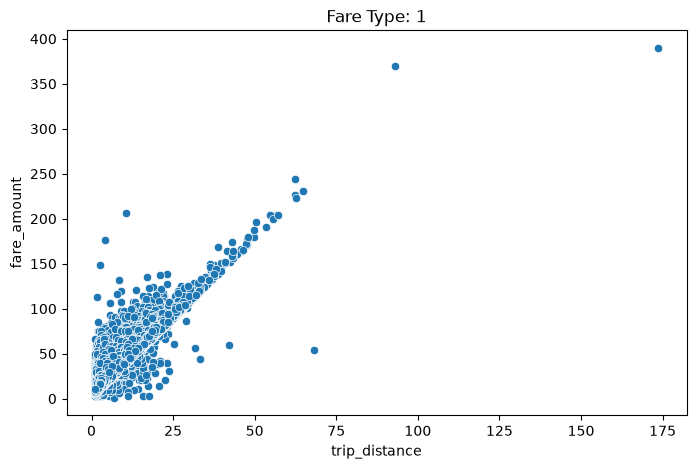

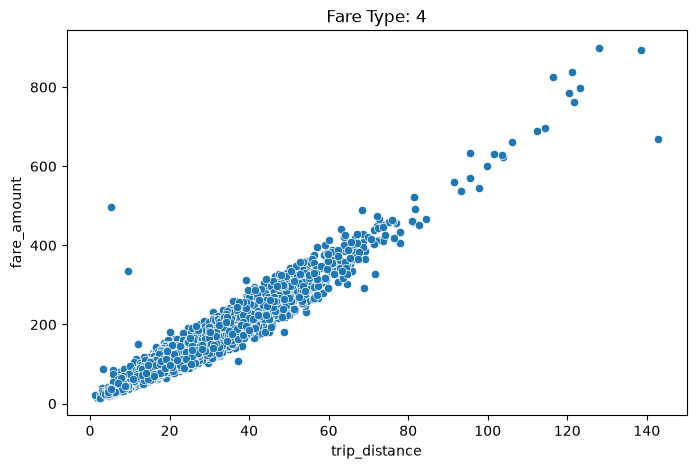

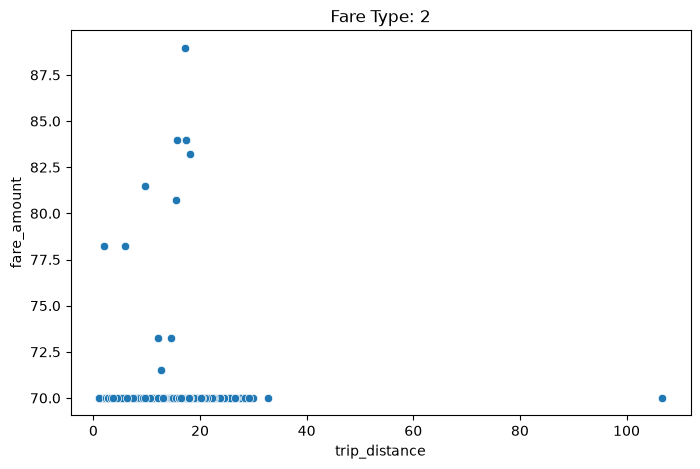

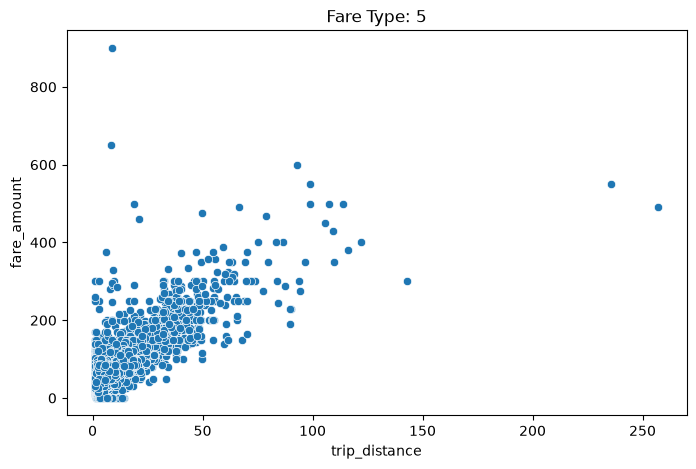

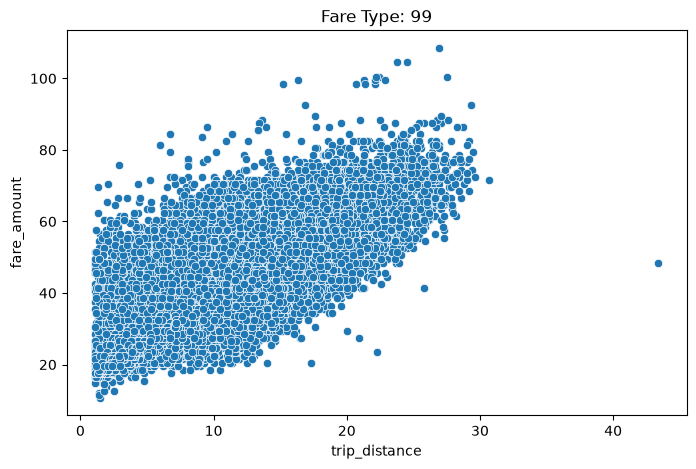

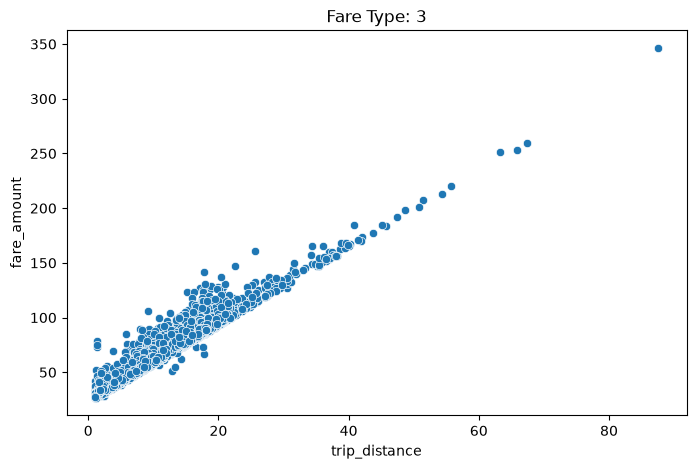

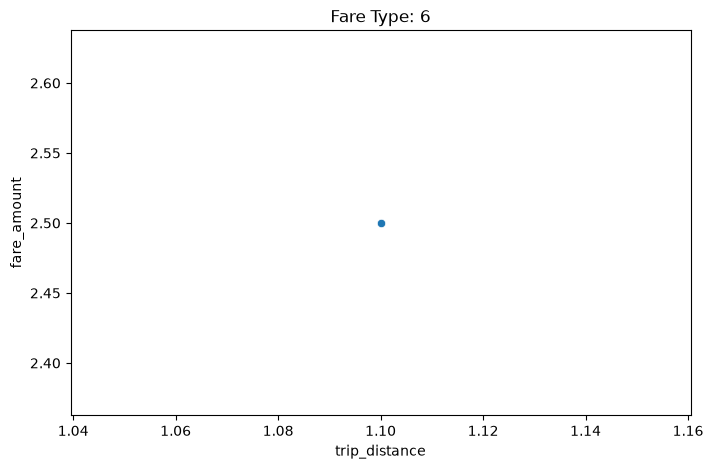

In [112]:
for fare_type in df['fare_type_id'].unique():
    tempdf = df[df['fare_type_id'] == fare_type]

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=tempdf,
        x='trip_distance',
        y='fare_amount'
    )
    plt.title(f'Fare Type: {fare_type}')
    plt.show()

# remove fare_type_id = 6 , having passenger count < 3

In [113]:
df = df[(~((df['fare_type_id']==6) & (df['passenger_count']<3)))]

# explore outlier fare_amount

In [114]:
df[(df['fare_type_id'] == 4) & (df['fare_amount']>200) & (df['trip_distance']<20)]

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,great_circle_distance,distance_difference,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch
201459,2,2026-01-04 20:12:49,2026-01-05 02:02:56,1,5.27,4,False,191,265,2,...,NaN,NaN,NaN,Queens,Queens Village,Boro Zone,Unknown,Outside of NYC,Unknown,False
890302,2,2026-01-15 15:26:24,2026-01-15 19:13:02,2,9.55,4,False,101,265,2,...,NaN,NaN,NaN,Queens,Glen Oaks,Boro Zone,Unknown,Outside of NYC,Unknown,False


In [115]:
df[(df['fare_type_id'] == 5) & (df['fare_amount']>400) & (df['trip_distance']<25)]

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,great_circle_distance,distance_difference,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch
1098746,2,2026-01-18 17:40:30,2026-01-18 17:56:30,1,8.350000,5,False,265,265,2,...,NaN,NaN,NaN,Unknown,Outside of NYC,Unknown,Unknown,Outside of NYC,Unknown,None
1103141,1,2026-01-18 18:48:03,2026-01-18 19:59:05,1,18.799999,5,False,265,215,1,...,NaN,NaN,NaN,Unknown,Outside of NYC,Unknown,Queens,South Jamaica,Boro Zone,None
1377881,1,2026-01-23 03:19:27,2026-01-23 04:17:06,1,21.200001,5,False,265,265,4,...,NaN,NaN,NaN,Unknown,Outside of NYC,Unknown,Unknown,Outside of NYC,Unknown,None
1448138,2,2026-01-24 00:18:59,2026-01-24 00:43:52,1,9.030000,5,False,147,146,4,...,4.838079,4.191921,1.866443,Bronx,Longwood,Boro Zone,Queens,Long Island City/Queens Plaza,Boro Zone,None


# remove outliers 

In [116]:
df['fare_per_distance'] = df['fare_amount'] / df['trip_distance']

In [127]:
bounds = df.groupby('fare_type_id')['fare_per_distance'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

In [146]:
bounds['IQR'] = bounds['Q3'] - bounds['Q1']
bounds['lower'] = bounds['Q1'] - 1.7 * bounds['IQR']
bounds['upper'] = bounds['Q3'] + 1.7 * bounds['IQR']

In [147]:
bounds.reset_index(inplace=True)

In [148]:
tempdf = df.merge(bounds, on='fare_type_id')

In [149]:
tempdf.sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance,level_0,index,Q1,Q3,IQR,lower,upper
1226896,2,2026-01-21 09:58:27,2026-01-21 10:07:59,1,1.05,1,False,48,162,1,...,Yellow Zone,None,9.52381,0,0,5.631769,8.15,2.518231,1.350776,12.430993


In [150]:
ani = tempdf[
        (tempdf['fare_per_distance'] >= tempdf['lower']) &
        (tempdf['fare_per_distance'] <= tempdf['upper'])
    ].copy()

In [151]:
df.shape

(1829061, 38)

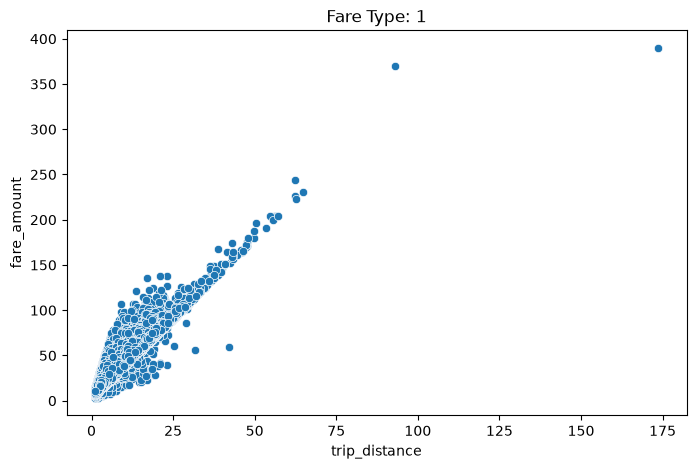

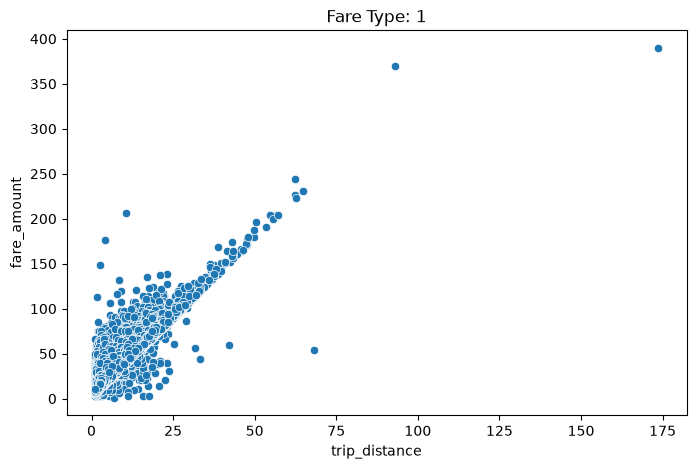

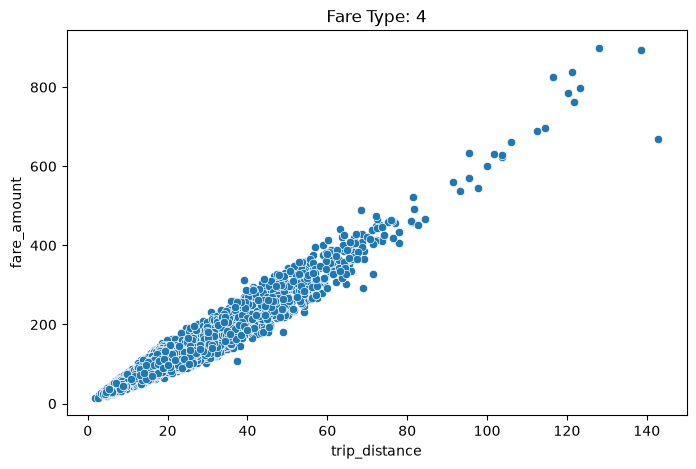

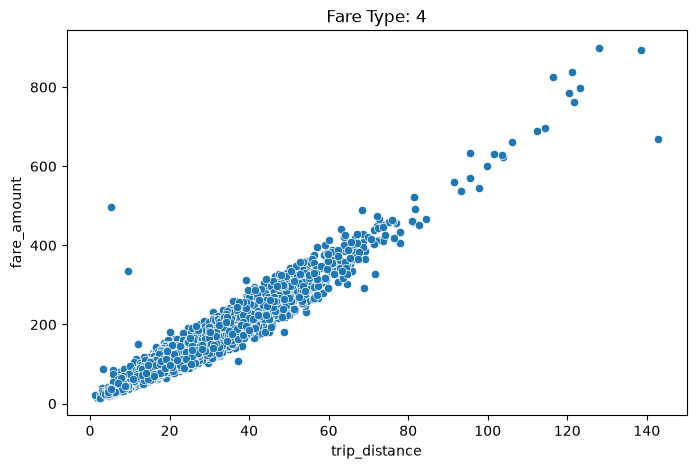

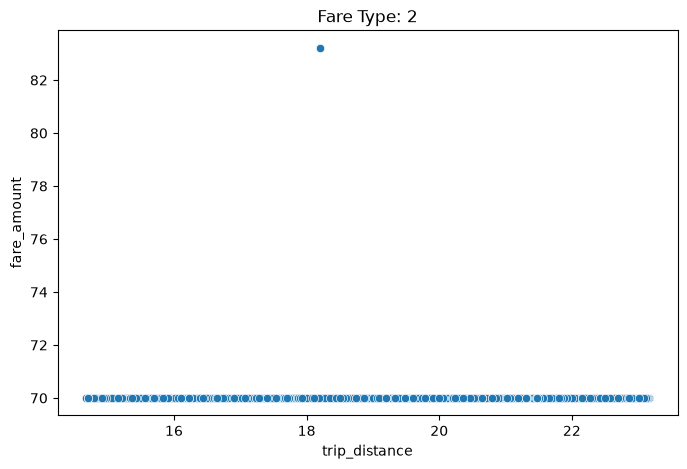

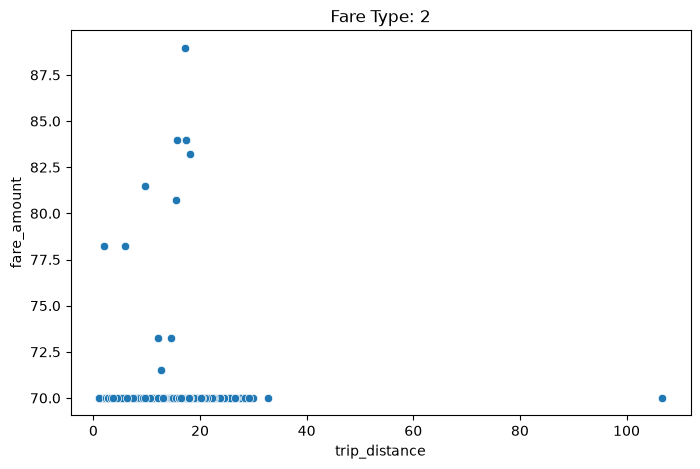

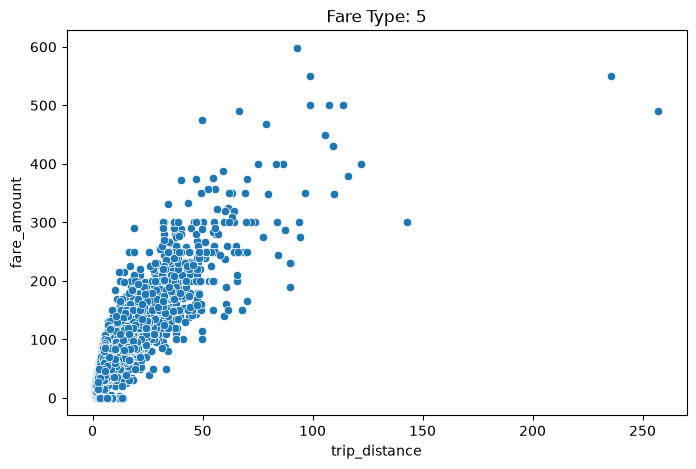

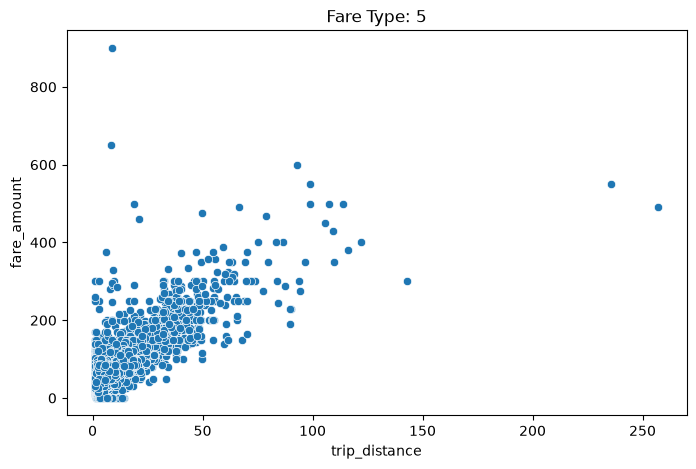

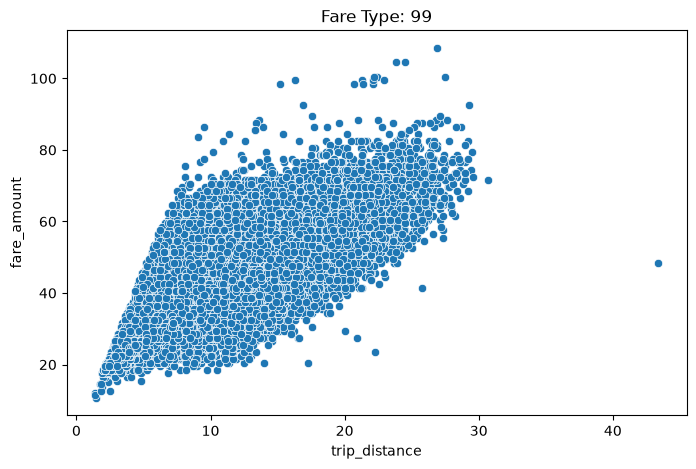

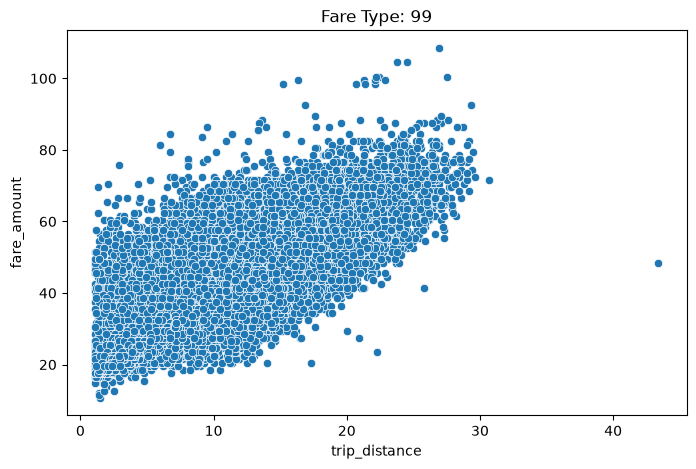

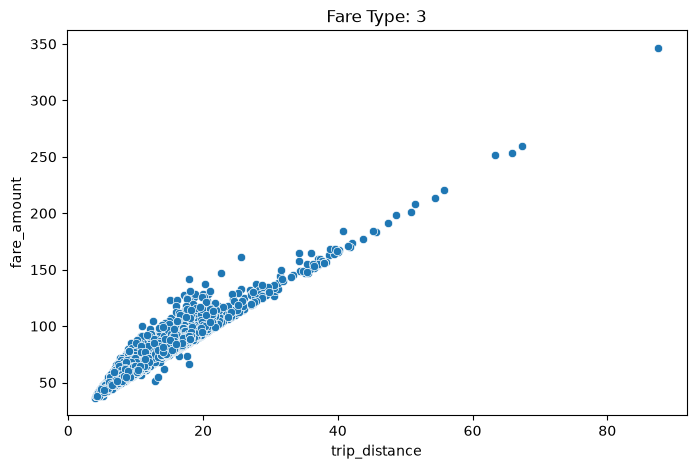

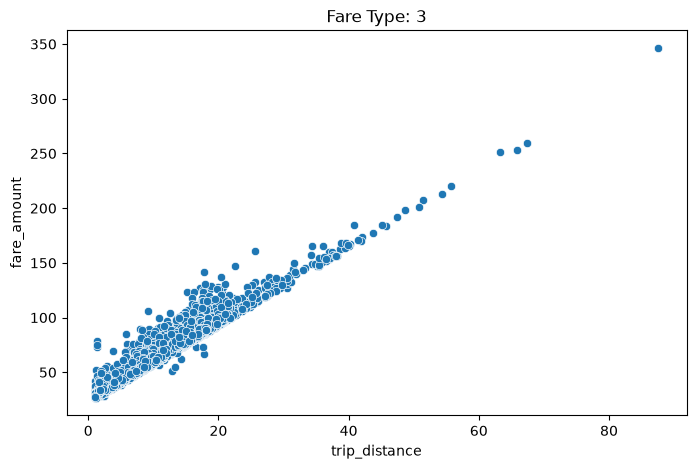

In [152]:
for fare_type in ani['fare_type_id'].unique():
    temp = ani[ani['fare_type_id'] == fare_type]
    temp2 = df[df['fare_type_id'] == fare_type]

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=temp,
        x='trip_distance',
        y='fare_amount'
    )
    plt.title(f'Fare Type: {fare_type}')
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=temp2,
        x='trip_distance',
        y='fare_amount'
    )
    plt.title(f'Fare Type: {fare_type}')
    plt.show()

# trip_distance is very small but the trip_duration is very high 

In [157]:
df[(df['fare_type_id']==99) & (df['trip_distance']<5) & (df['fare_amount']>30)].sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,distance_difference,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance
1736767,1,2026-01-30 08:42:59,2026-01-30 09:37:07,1,3.8,99,False,238,69,1,...,0.228093,0.943374,Manhattan,Upper West Side North,Yellow Zone,Bronx,East Concourse/Concourse Village,Boro Zone,None,8.026316


# remove the fare_amount outliers 

In [160]:
df = ani.copy()

In [161]:
df.shape

(1773721, 45)

In [167]:
df.drop(columns=['level_0', 'index', 'Q1', 'Q3', 'IQR', 'lower', 'upper'], inplace=True)

In [168]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_distance', 'fare_type_id', 'store_and_fwd_flag',
       'pickup_location_id', 'dropoff_location_id', 'payment_type',
       'fare_amount', 'extra_amount', 'mta_tax_amount', 'tip_amount',
       'tolls_amount', 'improvement_surcharge_amount', 'total_amount',
       'congestion_surcharge_amount', 'airport_fee_amount',
       'cbd_congestion_fee_amount', 'vendor_name', 'trip_duration',
       'taxi_speed', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'great_circle_distance',
       'distance_difference', 'distance_ratio', 'pickup_borough',
       'pickup_zone', 'pickup_service_type', 'dropoff_borough', 'dropoff_zone',
       'dropoff_service_type', 'fare_type_zone_mismatch', 'fare_per_distance'],
      dtype='str')

In [171]:
df['fare_amount'] = df['fare_amount'].astype('float32')
df['fare_per_distance'] = df['fare_per_distance'].astype('float32')

In [172]:
df.info()

<class 'pandas.DataFrame'>
Index: 1773721 entries, 0 to 1829060
Data columns (total 38 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float32        
 5   fare_type_id                  int8           
 6   store_and_fwd_flag            boolean        
 7   pickup_location_id            int16          
 8   dropoff_location_id           int16          
 9   payment_type                  int64          
 10  fare_amount                   float32        
 11  extra_amount                  float64        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amount  f

# save back to clean data file

In [173]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)